# 02 · MathKG Dataset Builder

Build a real mathematical knowledge graph from **ProofWiki** data,
structured for the NRO pipeline.

This notebook is a thin orchestration wrapper.  All scraping / parsing /
filtering logic lives in `mre.knowledge_graph.mathkg_builder`.

## Source priority
1. Local XML dump (`/kaggle/input/proofwiki-dump/latest.xml.gz`)
2. Auto-download XML dump from `proofwiki.org`
3. MediaWiki API (correct category names: `Category:Proven Results` etc.)
4. Synthetic fallback — always works offline

## Output
```
data/mathkg/
  entities.tsv          entity_id, name, type, description
  relations.tsv         head_id, relation, tail_id, confidence, source_url
  entity_texts.tsv      entity_id, raw_text
  entity_embeddings.npy  SBERT 384-dim (if sentence-transformers installed)
  splits/{rel}_{split}.tsv
  stats.json
```

In [1]:
import sys, os
repo_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
if repo_root not in sys.path:
    sys.path.insert(0, repo_root)

from mre.utils import load_config, set_seed, get_logger
from mre.knowledge_graph.mathkg_builder import MathKGBuilder
from mre.knowledge_graph.mathkg_loader  import MathKGLoader

cfg    = load_config()
set_seed(cfg.experiment.seed)
logger = get_logger('notebook_02')

print(f'MAX_ENTITIES  : {cfg.knowledge_graph.max_entities}')
print(f'Output dir    : {cfg.knowledge_graph.data_dir}')

MAX_ENTITIES  : 30000
Output dir    : C:\workspace\math-reasoning-engine\data\mathkg


## 1 · Crawl Entities

In [2]:
builder = MathKGBuilder(
    data_dir    = cfg.knowledge_graph.data_dir,
    max_entities = cfg.knowledge_graph.max_entities,
    seed        = cfg.experiment.seed,
)
builder.crawl_entities()
print(f'Entities collected: {len(builder.entities):,}')

07:51:12  INFO      mre.knowledge_graph.mathkg_builder  Attempting XML dump download...
07:51:12  INFO      mre.knowledge_graph.mathkg_builder  Downloading XML dump (~80 MB)...
07:51:13  INFO      mre.knowledge_graph.mathkg_builder    2000 entities parsed...
07:51:13  INFO      mre.knowledge_graph.mathkg_builder    4000 entities parsed...
07:51:13  INFO      mre.knowledge_graph.mathkg_builder    6000 entities parsed...
07:51:13  INFO      mre.knowledge_graph.mathkg_builder    8000 entities parsed...
07:51:14  INFO      mre.knowledge_graph.mathkg_builder    10000 entities parsed...
07:51:14  INFO      mre.knowledge_graph.mathkg_builder    12000 entities parsed...
07:51:14  INFO      mre.knowledge_graph.mathkg_builder    14000 entities parsed...
07:51:14  INFO      mre.knowledge_graph.mathkg_builder    16000 entities parsed...
07:51:14  INFO      mre.knowledge_graph.mathkg_builder    18000 entities parsed...
07:51:14  INFO      mre.knowledge_graph.mathkg_builder    20000 entities parsed.

## 2 · Extract Relations

In [3]:
builder.extract_relations()
print(f'Raw triples: {len(builder.raw_triples):,}')

07:51:24  INFO      mre.knowledge_graph.mathkg_builder  Extracting relations from 30000 pages with wikitext...
07:51:27  INFO      mre.knowledge_graph.mathkg_builder  Raw triples extracted: 72618
Raw triples: 72,618


## 3 · Filter & Split

In [4]:
builder.filter_and_clean(
    conf_threshold = cfg.knowledge_graph.confidence_threshold,
    min_degree     = cfg.knowledge_graph.min_entity_degree,
)
builder.make_splits()
print(builder.summary())

07:51:35  INFO      mre.knowledge_graph.mathkg_builder  After filtering: 27676 entities, 57145 triples
MathKGBuilder (entities=27676, triples=57145)
  depends_on          : 14986 total  train=10490  val=2247  test=2249
  generalizes         :  183 total  train=128  val=27  test=28
  equivalent_to       : 1168 total  train=817  val=175  test=176
  applied_in          : 40788 total  train=28551  val=6118  test=6119
  corollary_of        :   20 total  train=14  val=3  test=3


## 4 · Save & Verify

In [5]:
builder.save()

# Verify the saved dataset loads correctly
kg = MathKGLoader(cfg.knowledge_graph.data_dir)
print(kg.summary())

print('\nUsable relations:')
for rel in kg.usable_relations(min_train=4):
    train, val, test = kg.get_split(rel)
    print(f'  {rel:20s}  train={len(train):4d}  val={len(val):4d}  test={len(test):4d}')

07:51:43  INFO      mre.knowledge_graph.mathkg_builder  MathKG saved to C:\workspace\math-reasoning-engine\data\mathkg
07:51:43  INFO      mre.knowledge_graph.mathkg_loader  MathKGLoader — 27676 entities, 5 relations
MathKGLoader (entities=27676, dir=C:\workspace\math-reasoning-engine\data\mathkg)
  depends_on               : 14986 triples
  generalizes              : 183 triples
  equivalent_to            : 1168 triples
  applied_in               : 40788 triples
  corollary_of             : 20 triples

Usable relations:
  depends_on            train=10490  val=2247  test=2249
  generalizes           train= 128  val=  27  test=  28
  equivalent_to         train= 817  val= 175  test= 176
  applied_in            train=28551  val=6118  test=6119
  corollary_of          train=  14  val=   3  test=   3


## 5 · Dataset Statistics

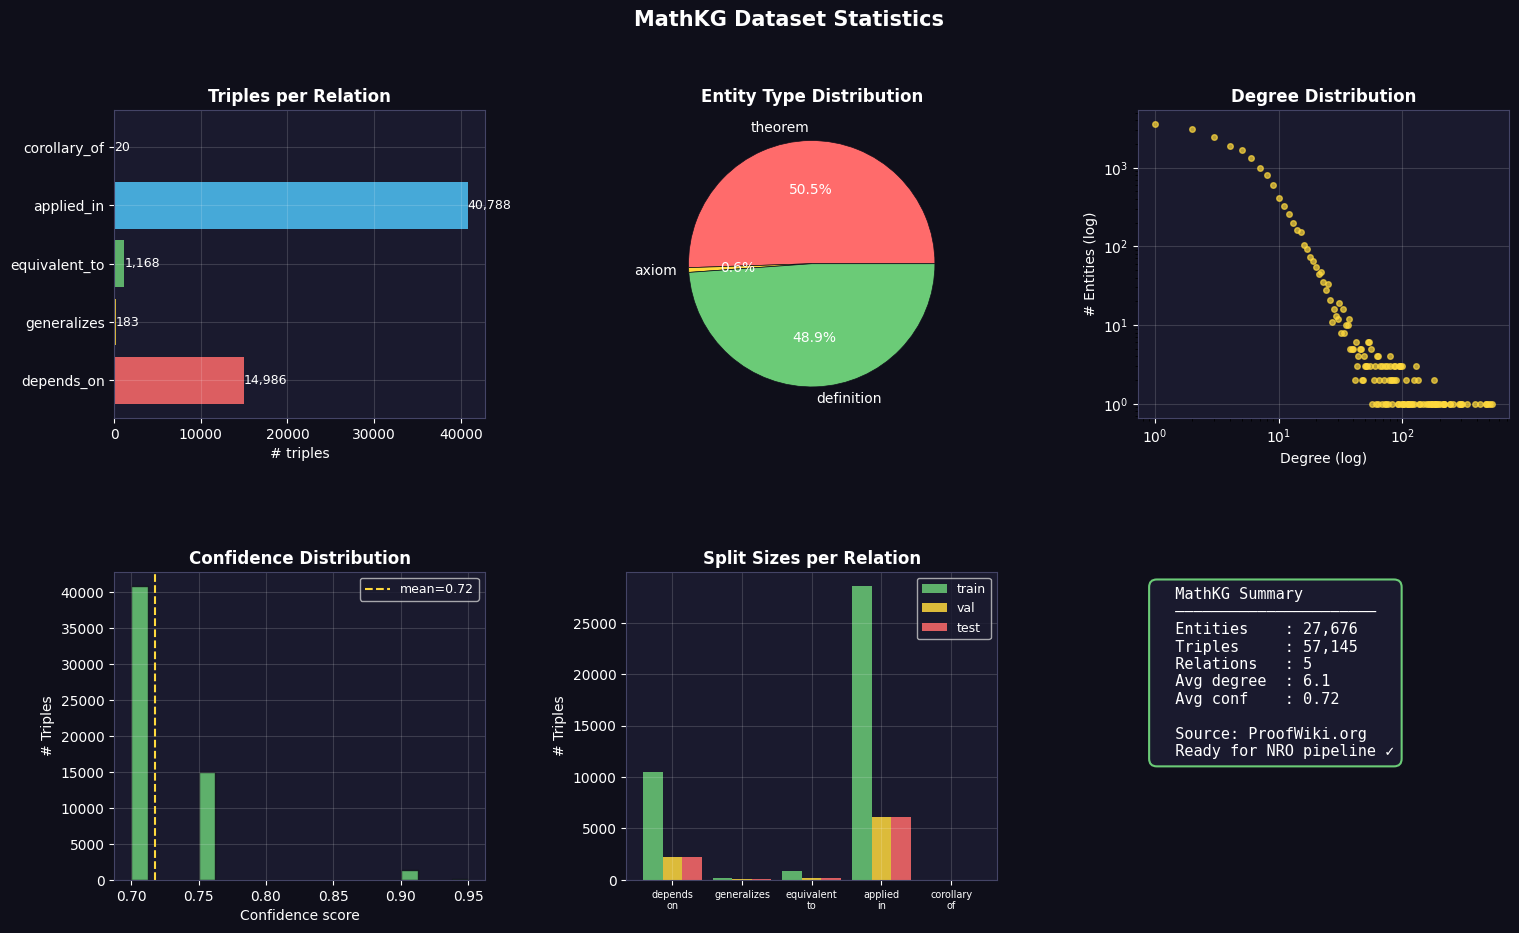

In [6]:
from mre.knowledge_graph.mathkg_builder import plot_dataset_stats
import matplotlib.pyplot as plt

fig = plot_dataset_stats(builder)
fig.savefig(f'{cfg.knowledge_graph.data_dir}/mathkg_stats.png',
            dpi=150, bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()